# MagmaClust - Distinct Input, Shared Hyperparameters, no Cluster Hyperparameters

---

## Setup

In [1]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [2]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

from functools import partial
from copy import deepcopy

In [3]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

In [4]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)

import pandas as pd
from matplotlib import pyplot as plt

In [5]:
# Local
from kernax import DiagKernel, ExpKernel
from MagmaClustPy.custom_kernels import SEMagmaKernel
from MagmaClustPy.utils import split_db
from MagmaClustPy.means import ZeroMean
from MagmaClustPy.models import BaseLikelihood, MagmaClust

INFO:2025-12-17 14:10:44,351:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2025-12-17 14:10:44,351 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/MagmaClustPy/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [6]:
# Config
key = jax.random.PRNGKey(0)
test_db_size = "small"
nb_cluster = 4
pred_id = 0
grid_size = 250  # number of points in the grid
grid_margin = 5  # grid goes from min(all_inputs) - margin to max(all_inputs) + margin
train_pred_ratio = 0.8  # ratio of train/pred tasks
pred_test_ratio = 0.7  # ratio of pred/test points in each pred task

---

## Model use

##### Setup

In [7]:
db = pd.read_csv(f"../../datasets/K={nb_cluster}/{test_db_size}_distinct_input_shared_hp.csv")
db_train, db_pred, db_test = split_db(db, train_ratio=train_pred_ratio, pred_ratio=pred_test_ratio)

/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:210: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_test = db_pred.groupby("Task_ID", group_keys=False).apply(
/Users/simonlejoly/Documents/Work/MagmaClust/MagmaClustPy/MagmaClustPy/utils.py:213: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  db_pred = db_pred.groupby("Task_ID", group_keys=False).apply(


In [8]:
mean_kern = SEMagmaKernel(length_scale=.2, variance=5.)
task_kern = SEMagmaKernel(length_scale=.2, variance=1.) + DiagKernel(ExpKernel(2.5))

In [9]:
model = MagmaClust(k=nb_cluster, likelihood=BaseLikelihood(), prior_mean=ZeroMean(), mean_kernel=mean_kern, task_kernel_train=task_kern, task_kernel_pred=deepcopy(task_kern), shared_hp=True, cluster_hp=False)

In [10]:
model.load_train_data(db_train)
model.load_pred_data(db_pred)
model.load_test_data(db_test)

In [11]:
model.fit()

2025-12-17 14:10:45,780 - INFO - Iteration    0	Llhs:          inf,          inf	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.20, variance=5.00)
	Task kernel: SEMagmaKernel(length_scale=0.20, variance=1.00) + Diag(Exp(2.50))
2025-12-17 14:10:47,316 - INFO - Iteration    1	Llhs:     244.9715,     675.2237	Conv. Ratio: inf	
	Mean kernel: SEMagmaKernel(length_scale=0.33, variance=6.02)
	Task kernel: SEMagmaKernel(length_scale=-0.64, variance=2.06) + Diag(Exp(-3.32))
2025-12-17 14:10:48,643 - INFO - Iteration    2	Llhs:     232.4694,     586.6118	Conv. Ratio: 0.10988	
	Mean kernel: SEMagmaKernel(length_scale=0.38, variance=6.10)
	Task kernel: SEMagmaKernel(length_scale=-0.28, variance=1.70) + Diag(Exp(-2.85))
2025-12-17 14:10:48,719 - INFO - Iteration    3	Llhs:     217.0415,     539.4541	Conv. Ratio: 0.07641	
	Mean kernel: SEMagmaKernel(length_scale=0.43, variance=6.09)
	Task kernel: SEMagmaKernel(length_scale=-0.01, variance=1.58) + Diag(Exp(-2.79))
2025-12-17 14:10:48,75

In [12]:
grid = model.generate_grid(grid_size)
grid.shape

(250, 1)

In [13]:
pred_means, pred_covs = model.predict(grid)
pred_means.shape, pred_covs.shape

((4, 4, 291), (4, 4, 291, 291))

##### Test

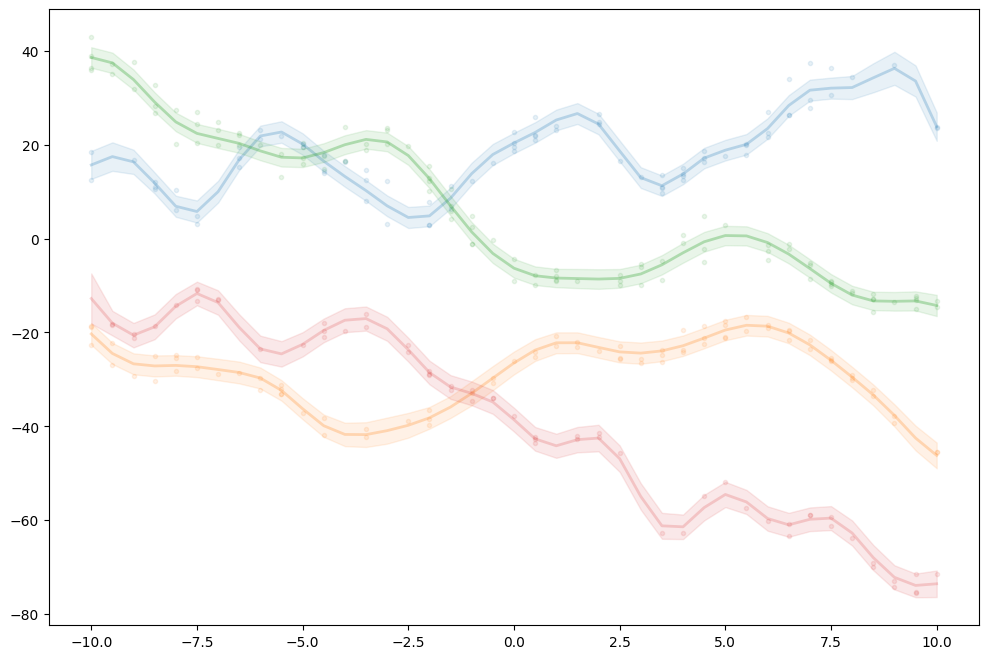

In [14]:
model.plot_mean_processes()
plt.show()

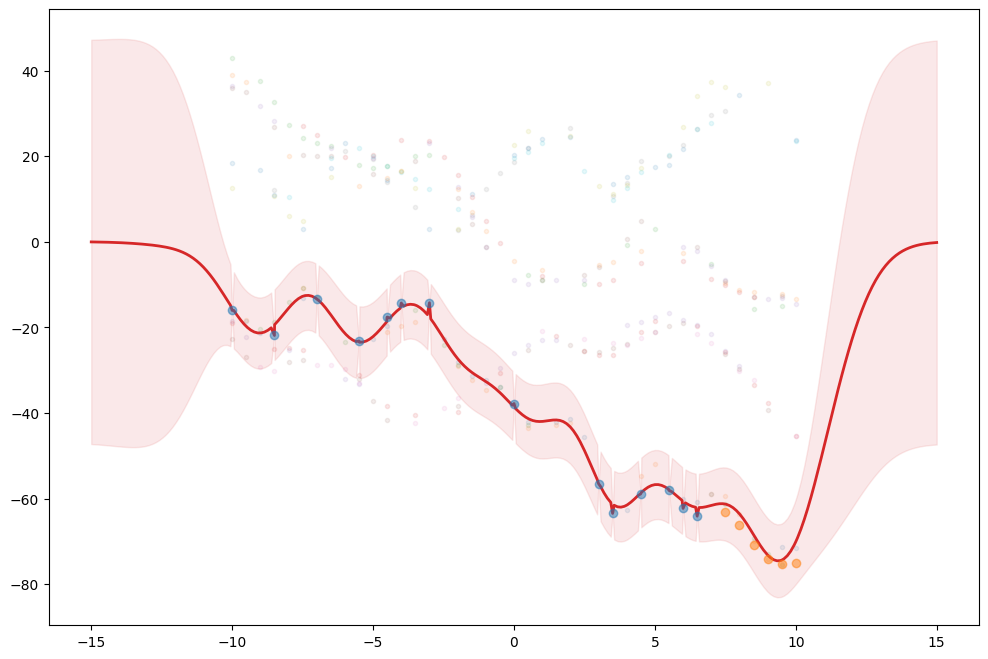

In [15]:
model.plot_predictions(plot_as="process", task_id=0)
plt.show()